# Part 1

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv("spambase.data", header=None)
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
k_values = [1, 3, 5, 7, 9, 11]

results = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    acc = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    prec = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='precision').mean()
    rec = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='recall').mean()
    error = 1 - acc

    results.append((k, acc, error, prec, rec))

for r in results:
    print(f"k={r[0]} | Acc={r[1]} | Error={r[2]} | Precision={r[3]} | Recall={r[4]}")

k=1 | Acc=0.9014492753623189 | Error=0.09855072463768111 | Precision=0.8776588221116455 | Recall=0.8669657331320924
k=3 | Acc=0.9008695652173915 | Error=0.09913043478260852 | Precision=0.8824654358804537 | Recall=0.8594862764827547
k=5 | Acc=0.9026086956521739 | Error=0.09739130434782606 | Precision=0.8905775868512841 | Recall=0.8542623958857399
k=7 | Acc=0.9066666666666666 | Error=0.09333333333333338 | Precision=0.8962856389364102 | Recall=0.8594862764827547
k=9 | Acc=0.9049275362318842 | Error=0.09507246376811584 | Precision=0.8994308371657679 | Recall=0.8505114875062887
k=11 | Acc=0.9005797101449277 | Error=0.09942028985507234 | Precision=0.8977072020760233 | Recall=0.8400525462574766


# Part 2

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [6]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_scaled, y_train)

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_scaled, y_train)

models = {
    "Logistic Regression": log_reg,
    "LDA": lda,
    "kNN (k=7)": knn
}

results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_prec = precision_score(y_train, y_train_pred)
    train_rec = recall_score(y_train, y_train_pred)
    train_err = 1 - train_acc

    y_test_pred = model.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_test_pred)
    test_prec = precision_score(y_test, y_test_pred)
    test_rec = recall_score(y_test, y_test_pred)
    test_err = 1 - test_acc

    results.append((name, train_acc, train_err, train_prec, train_rec,
                    test_acc, test_err, test_prec, test_rec))

for r in results:
    print(f"{r[0]} | Train Acc={r[1]} | Train Err={r[2]} | Train Prec={r[3]} | Train Rec={r[4]} "
          f"| Test Acc={r[5]} | Test Err={r[6]} | Test Prec={r[7]} | Test Rec={r[8]}")

Logistic Regression | Train Acc=0.9257971014492754 | Train Err=0.0742028985507246 | Train Prec=0.9239811912225705 | Train Rec=0.8811659192825112 | Test Acc=0.9226759339704604 | Test Err=0.07732406602953956 | Test Prec=0.9406392694063926 | Test Rec=0.8673684210526316
LDA | Train Acc=0.8866666666666667 | Train Err=0.11333333333333329 | Train Prec=0.9157155399473222 | Train Rec=0.7795216741405082 | Test Acc=0.8853171155516942 | Test Err=0.11468288444830577 | Test Prec=0.9298245614035088 | Test Rec=0.7810526315789473
kNN (k=7) | Train Acc=0.922608695652174 | Train Err=0.07739130434782604 | Train Prec=0.9167315175097276 | Train Rec=0.8804185351270553 | Test Acc=0.9018245004344049 | Test Err=0.09817549956559513 | Test Prec=0.9113636363636364 | Test Rec=0.8442105263157895


# Part 3

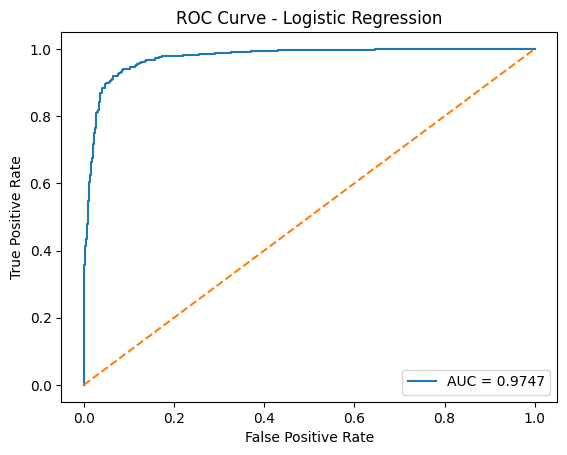

AUC: 0.9747337278106508


In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC:", roc_auc)

# Part 4

T=0.0 | FPR=1.0000 | TPR=1.0000
T=0.1 | FPR=0.3077 | TPR=0.9874
T=0.2 | FPR=0.1524 | TPR=0.9684
T=0.3 | FPR=0.0917 | TPR=0.9389
T=0.4 | FPR=0.0636 | TPR=0.9095
T=0.5 | FPR=0.0385 | TPR=0.8674
T=0.6 | FPR=0.0340 | TPR=0.8295
T=0.7 | FPR=0.0266 | TPR=0.7874
T=0.8 | FPR=0.0222 | TPR=0.7179
T=0.9 | FPR=0.0118 | TPR=0.6000
T=1.0 | FPR=0.0000 | TPR=0.0021


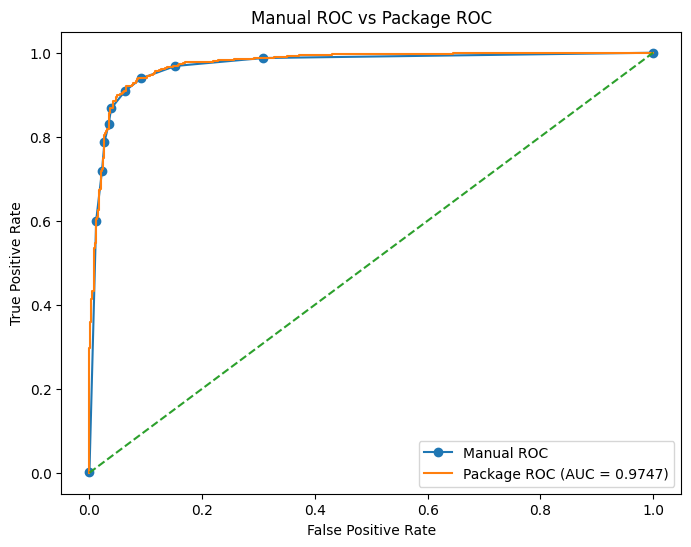

In [8]:
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]

thresholds_manual = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

manual_points = []

for T in thresholds_manual:
    y_pred_T = (y_probs >= T).astype(int)

    TP = np.sum((y_test == 1) & (y_pred_T == 1))
    TN = np.sum((y_test == 0) & (y_pred_T == 0))
    FP = np.sum((y_test == 0) & (y_pred_T == 1))
    FN = np.sum((y_test == 1) & (y_pred_T == 0))

    TPR = TP / (TP + FN) if (TP + FN) > 0 else 0
    FPR = FP / (FP + TN) if (FP + TN) > 0 else 0

    manual_points.append((T, FPR, TPR))
    print(f"T={T:.1f} | FPR={FPR:.4f} | TPR={TPR:.4f}")

manual_points = sorted(manual_points, key=lambda x: x[1])

manual_fpr = [p[1] for p in manual_points]
manual_tpr = [p[2] for p in manual_points]

pkg_fpr, pkg_tpr, _ = roc_curve(y_test, y_probs)
pkg_auc = auc(pkg_fpr, pkg_tpr)

plt.figure(figsize=(8, 6))
plt.plot(manual_fpr, manual_tpr, marker='o', label='Manual ROC')
plt.plot(pkg_fpr, pkg_tpr, label=f'Package ROC (AUC = {pkg_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Manual ROC vs Package ROC")
plt.legend()
plt.show()